In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [2]:
# ── สีสำหรับ plot
COLORS = {
    "train":  "#2196F3",
    "val":    "#FF9800",
    "test":   "#4CAF50",
    "actual": "#263238",
    "pred":   "#E53935",
    "zero":   "#90A4AE",
}

# 1 : LOAD DATA

In [3]:
BASE = "../../../data/processed/splits/"
 
X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")
 
y_train = pd.read_csv(BASE + "y_train_reg.csv", parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv(BASE + "y_val_reg.csv",   parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv(BASE + "y_test_reg.csv",  parse_dates=["Date"], index_col="Date").squeeze()

In [4]:
# ── ตรวจสอบ
for name, X, y in [("Train", X_train, y_train),
                   ("Val",   X_val,   y_val),
                   ("Test",  X_test,  y_test)]:
    nan_X = X.isnull().sum().sum()
    nan_y = y.isnull().sum()
    sorted_ok = X.index.is_monotonic_increasing
    print(f"  {name:5s} | X: {X.shape}  y: {y.shape}  "
          f"NaN_X: {nan_X}  NaN_y: {nan_y}  Sorted: {sorted_ok}")

  Train | X: (1478, 69)  y: (1478,)  NaN_X: 0  NaN_y: 0  Sorted: True
  Val   | X: (501, 69)  y: (501,)  NaN_X: 0  NaN_y: 0  Sorted: True
  Test  | X: (563, 69)  y: (563,)  NaN_X: 0  NaN_y: 0  Sorted: True


In [5]:
# ── ตรวจไม่ overlap
assert X_train.index.max() < X_val.index.min(),  "Train/Val overlap!"
assert X_val.index.max()   < X_test.index.min(), "Val/Test overlap!"
print("\n  ✔ ไม่มี overlap ระหว่าง Train / Val / Test\n")


  ✔ ไม่มี overlap ระหว่าง Train / Val / Test



# 2 : MODEL — Random Forest Regressor (Baseline Parameters)

เหตุผลของ Parameter ที่เลือก

- n_estimators = 300
  • ยิ่งมาก tree ยิ่ง stable (variance ต่ำ) แต่ใช้เวลา train นานขึ้น
  • 300 คือจุดสมดุลระหว่าง performance vs. training time สำหรับ dataset ~1500 rows
 
- max_depth = 8
  • Financial data มี noise สูง → tree ลึกเกินไปจะ overfit สัญญาณ noise
  • depth 6-10 เหมาะกับ time series data ที่มี signal-to-noise ratio ต่ำ
 
- min_samples_split = 20
  • บังคับให้ node split ได้ก็ต่อเมื่อมีข้อมูลอย่างน้อย 20 แถว
  • ลด overfitting โดยเฉพาะ leaf nodes ที่ "จำ" ข้อมูล train
 
- min_samples_leaf = 10
  • ทุก leaf ต้องมีอย่างน้อย 10 ตัวอย่าง → smooths predictions
  • สำคัญมากสำหรับ financial regression ที่ค่า extreme outliers มีผลสูง
 
- max_features = "sqrt"
  • สุ่ม sqrt(n_features) features ในแต่ละ split → ลด correlation ระหว่าง trees
  • ทำให้ ensemble มี diversity สูง → generalize ได้ดีกว่า
 
- n_jobs = -1
  • ใช้ทุก CPU cores → train เร็วขึ้น
 
- random_state = 42
  • reproducibility

In [6]:
rf_baseline = RandomForestRegressor(
    n_estimators    = 300,
    max_depth       = 8,
    min_samples_split = 20,
    min_samples_leaf  = 10,
    max_features    = "sqrt",
    n_jobs          = -1,
    random_state    = 42,
)
 
print("\n  กำลัง train Random Forest (baseline)...")
rf_baseline.fit(X_train, y_train)
print("Train เสร็จแล้ว\n")


  กำลัง train Random Forest (baseline)...
Train เสร็จแล้ว



# 3 : HELPER FUNCTIONS — Metrics

In [7]:
def directional_accuracy(y_true, y_pred):
    """
    Directional Accuracy (Hit Ratio):
    สัดส่วนที่โมเดลทายทิศทาง (ขึ้น/ลง) ถูกต้อง
    สำคัญมากสำหรับ trading → ถ้า DA > 50% อาจสร้าง edge ได้
    """
    correct = np.sign(y_true) == np.sign(y_pred)
    return correct.mean()

In [8]:
def information_coefficient(y_true, y_pred):
    """
    IC (Spearman Rank Correlation):
    วัดว่า ranking ของ prediction สอดคล้องกับ ranking ของ actual return
    ใน quant finance: IC > 0.05 ถือว่ามี edge, IC > 0.10 ดีมาก
    """
    from scipy.stats import spearmanr
    ic, _ = spearmanr(y_true, y_pred)
    return ic

In [9]:
def compute_metrics(y_true, y_pred, label=""):
    """คำนวณ metrics ครบชุดสำหรับ Financial Regression"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    da   = directional_accuracy(y_true, y_pred)
    ic   = information_coefficient(y_true, y_pred)
 
    # Baseline comparison: predict mean เสมอ (Naive benchmark)
    naive_pred = np.full_like(y_true, y_true.mean(), dtype=float)
    naive_rmse = np.sqrt(mean_squared_error(y_true, naive_pred))
 
    print(f"\n  ── {label} ──")
    print(f"  {'RMSE':<28}: {rmse:.4f}   (Naive RMSE: {naive_rmse:.4f})")
    print(f"  {'MAE':<28}: {mae:.4f}")
    print(f"  {'R² Score':<28}: {r2:.4f}")
    print(f"  {'Directional Accuracy (DA)':<28}: {da:.4f}  ({da*100:.1f}%)")
    print(f"  {'Information Coefficient (IC)':<28}: {ic:.4f}")
 
    return {
        "rmse": rmse, "mae": mae, "r2": r2,
        "da": da, "ic": ic, "naive_rmse": naive_rmse
    }
 
 

# 4 : EVALUATE — Train / Val / Test

In [10]:
y_pred_train = rf_baseline.predict(X_train)
y_pred_val   = rf_baseline.predict(X_val)
y_pred_test  = rf_baseline.predict(X_test)
 
metrics_train = compute_metrics(y_train, y_pred_train, "TRAIN SET")
metrics_val   = compute_metrics(y_val,   y_pred_val,   "VALIDATION SET")
metrics_test  = compute_metrics(y_test,  y_pred_test,  "TEST SET")
 


  ── TRAIN SET ──
  RMSE                        : 0.6179   (Naive RMSE: 0.7022)
  MAE                         : 0.4686
  R² Score                    : 0.2257
  Directional Accuracy (DA)   : 0.7334  (73.3%)
  Information Coefficient (IC): 0.7541

  ── VALIDATION SET ──
  RMSE                        : 0.7656   (Naive RMSE: 0.7642)
  MAE                         : 0.5897
  R² Score                    : -0.0036
  Directional Accuracy (DA)   : 0.5070  (50.7%)
  Information Coefficient (IC): 0.0486

  ── TEST SET ──
  RMSE                        : 0.8397   (Naive RMSE: 0.8181)
  MAE                         : 0.6528
  R² Score                    : -0.0535
  Directional Accuracy (DA)   : 0.4973  (49.7%)
  Information Coefficient (IC): 0.0330


# 5 : ANALYSIS — Overfit / Underfit / Financial Suitability

In [11]:
rmse_gap = metrics_train["rmse"] - metrics_val["rmse"]
r2_gap   = metrics_train["r2"]   - metrics_val["r2"]
 
print(f"""
  ┌─ Overfitting Check ────────────────────────────────────────────┐
  │  RMSE Train: {metrics_train['rmse']:.4f}  |  Val: {metrics_val['rmse']:.4f}  |  Test: {metrics_test['rmse']:.4f}
  │  R²   Train: {metrics_train['r2']:.4f}  |  Val: {metrics_val['r2']:.4f}  |  Test: {metrics_test['r2']:.4f}
  │  R²   Gap (Train-Val): {r2_gap:.4f}
  └────────────────────────────────────────────────────────────────┘
""")
 
if r2_gap > 0.3:
    print(" OVERFIT: โมเดล fit train ดีมาก แต่ generalize ไม่ดี")
    print("     → ลอง max_depth ให้ต่ำลง หรือเพิ่ม min_samples_leaf")
elif metrics_val["r2"] < 0.0:
    print(" UNDERFIT: โมเดลยังทำนายได้แย่กว่า naive mean")
    print("     → ลอง feature engineering เพิ่ม หรือ ensemble ที่ซับซ้อนกว่า")
else:
    print("   Overfitting อยู่ในระดับที่ยอมรับได้")


  ┌─ Overfitting Check ────────────────────────────────────────────┐
  │  RMSE Train: 0.6179  |  Val: 0.7656  |  Test: 0.8397
  │  R²   Train: 0.2257  |  Val: -0.0036  |  Test: -0.0535
  │  R²   Gap (Train-Val): 0.2294
  └────────────────────────────────────────────────────────────────┘

 UNDERFIT: โมเดลยังทำนายได้แย่กว่า naive mean
     → ลอง feature engineering เพิ่ม หรือ ensemble ที่ซับซ้อนกว่า


In [12]:
print(f"""
  ┌─ R² สำหรับ Financial Time Series ─────────────────────────────┐
  │                                                                │
  │  R² ใน financial prediction มีความหมายต่างจาก domain ทั่วไป:  │
  │                                                                │
  │  R² > 0.05  → มีความสามารถในการทำนายเหนือ random             │
  │  R² > 0.10  → ถือว่าดีมากสำหรับ daily return prediction       │
  │  R² > 0.30  → หายากมาก / อาจมี data leakage                  │
  │                                                                │
  │  งานวิจัย (Gu, Kelly, Xiu 2020) พบ R² ~1-3%                  │
  │  ในการทำนาย cross-sectional stock return ด้วย ML             │
  │                                                                │
  │  !!! อย่าใช้ R² เป็น metric หลักสำหรับ trading decision!     │
  │  ให้ดู Directional Accuracy และ IC แทน                        │
  └────────────────────────────────────────────────────────────────┘
 
  ┌─ Directional Accuracy (DA) Interpretation ─────────────────────┐
  │  DA = {metrics_test['da']*100:.1f}% บน Test Set
  │                                                                │
  │  DA < 50%  → แย่กว่า random (flip coin)                      │
  │  DA = 50%  → เทียบเท่า random                                 │
  │  DA > 52%  → อาจมี trading edge (ขึ้นอยู่กับ transaction cost)│
  │  DA > 55%  → ดีมากสำหรับ daily prediction                    │
  └────────────────────────────────────────────────────────────────┘
 
  ┌─ Information Coefficient (IC) Interpretation ──────────────────┐
  │  IC = {metrics_test['ic']:.4f} บน Test Set
  │                                                                │
  │  |IC| < 0.03  → สัญญาณอ่อนมาก (noise dominated)             │
  │  |IC| 0.03-0.07  → สัญญาณพอใช้ได้                           │
  │  |IC| > 0.10  → สัญญาณแข็งแกร่ง (rare in practice)          │
  └────────────────────────────────────────────────────────────────┘
""")
 


  ┌─ R² สำหรับ Financial Time Series ─────────────────────────────┐
  │                                                                │
  │  R² ใน financial prediction มีความหมายต่างจาก domain ทั่วไป:  │
  │                                                                │
  │  R² > 0.05  → มีความสามารถในการทำนายเหนือ random             │
  │  R² > 0.10  → ถือว่าดีมากสำหรับ daily return prediction       │
  │  R² > 0.30  → หายากมาก / อาจมี data leakage                  │
  │                                                                │
  │  งานวิจัย (Gu, Kelly, Xiu 2020) พบ R² ~1-3%                  │
  │  ในการทำนาย cross-sectional stock return ด้วย ML             │
  │                                                                │
  │  !!! อย่าใช้ R² เป็น metric หลักสำหรับ trading decision!     │
  │  ให้ดู Directional Accuracy และ IC แทน                        │
  └────────────────────────────────────────────────────────────────┘

  ┌─ Directional Accuracy (DA) Interpretation 

# 6 : FEATURE IMPORTANCE

In [13]:
feat_imp = pd.Series(
    rf_baseline.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
 
top_n = 20
print(f"\n  Top {top_n} Features (จาก {len(feat_imp)} features ทั้งหมด):\n")
print(f"  {'Rank':<5} {'Feature':<35} {'Importance':>10}  {'Bar'}")
print(f"  {'-'*4} {'-'*34} {'-'*10}  {'-'*20}")
for rank, (feat, imp) in enumerate(feat_imp.head(top_n).items(), 1):
    bar = "█" * int(imp * 500)
    print(f"  {rank:<5} {feat:<35} {imp:>10.4f}  {bar}")
 
# Feature groups (สรุปตามกลุ่ม prefix)
print("\n  Feature Group Summary:")
feat_df = pd.DataFrame({"feature": feat_imp.index, "importance": feat_imp.values})
feat_df["group"] = feat_df["feature"].str.extract(r"f_([a-zA-Z]+)", expand=False)
group_sum = feat_df.groupby("group")["importance"].sum().sort_values(ascending=False)
for grp, total in group_sum.items():
    bar = "█" * int(total * 200)
    print(f"    {grp:<20} {total:.4f}  {bar}")
 


  Top 20 Features (จาก 69 features ทั้งหมด):

  Rank  Feature                             Importance  Bar
  ---- ---------------------------------- ----------  --------------------
  1     f_gold_oil_spread_ret                   0.0437  █████████████████████
  2     f_oil_close_ret                         0.0351  █████████████████
  3     f_gold_vol_10d                          0.0301  ███████████████
  4     f_yield_close_ret                       0.0289  ██████████████
  5     f_gold_vol_5d                           0.0272  █████████████
  6     f_gold_ret_lag1                         0.0262  █████████████
  7     f_gold_sp500_ratio                      0.0244  ████████████
  8     f_sp500_ret_lag3                        0.0225  ███████████
  9     f_corr_90d_dxy                          0.0218  ██████████
  10    f_sp500_ret_lag1                        0.0212  ██████████
  11    f_yield_x_dxy                           0.0205  ██████████
  12    f_vix_close_ret                      

# 7 : VISUALIZATION

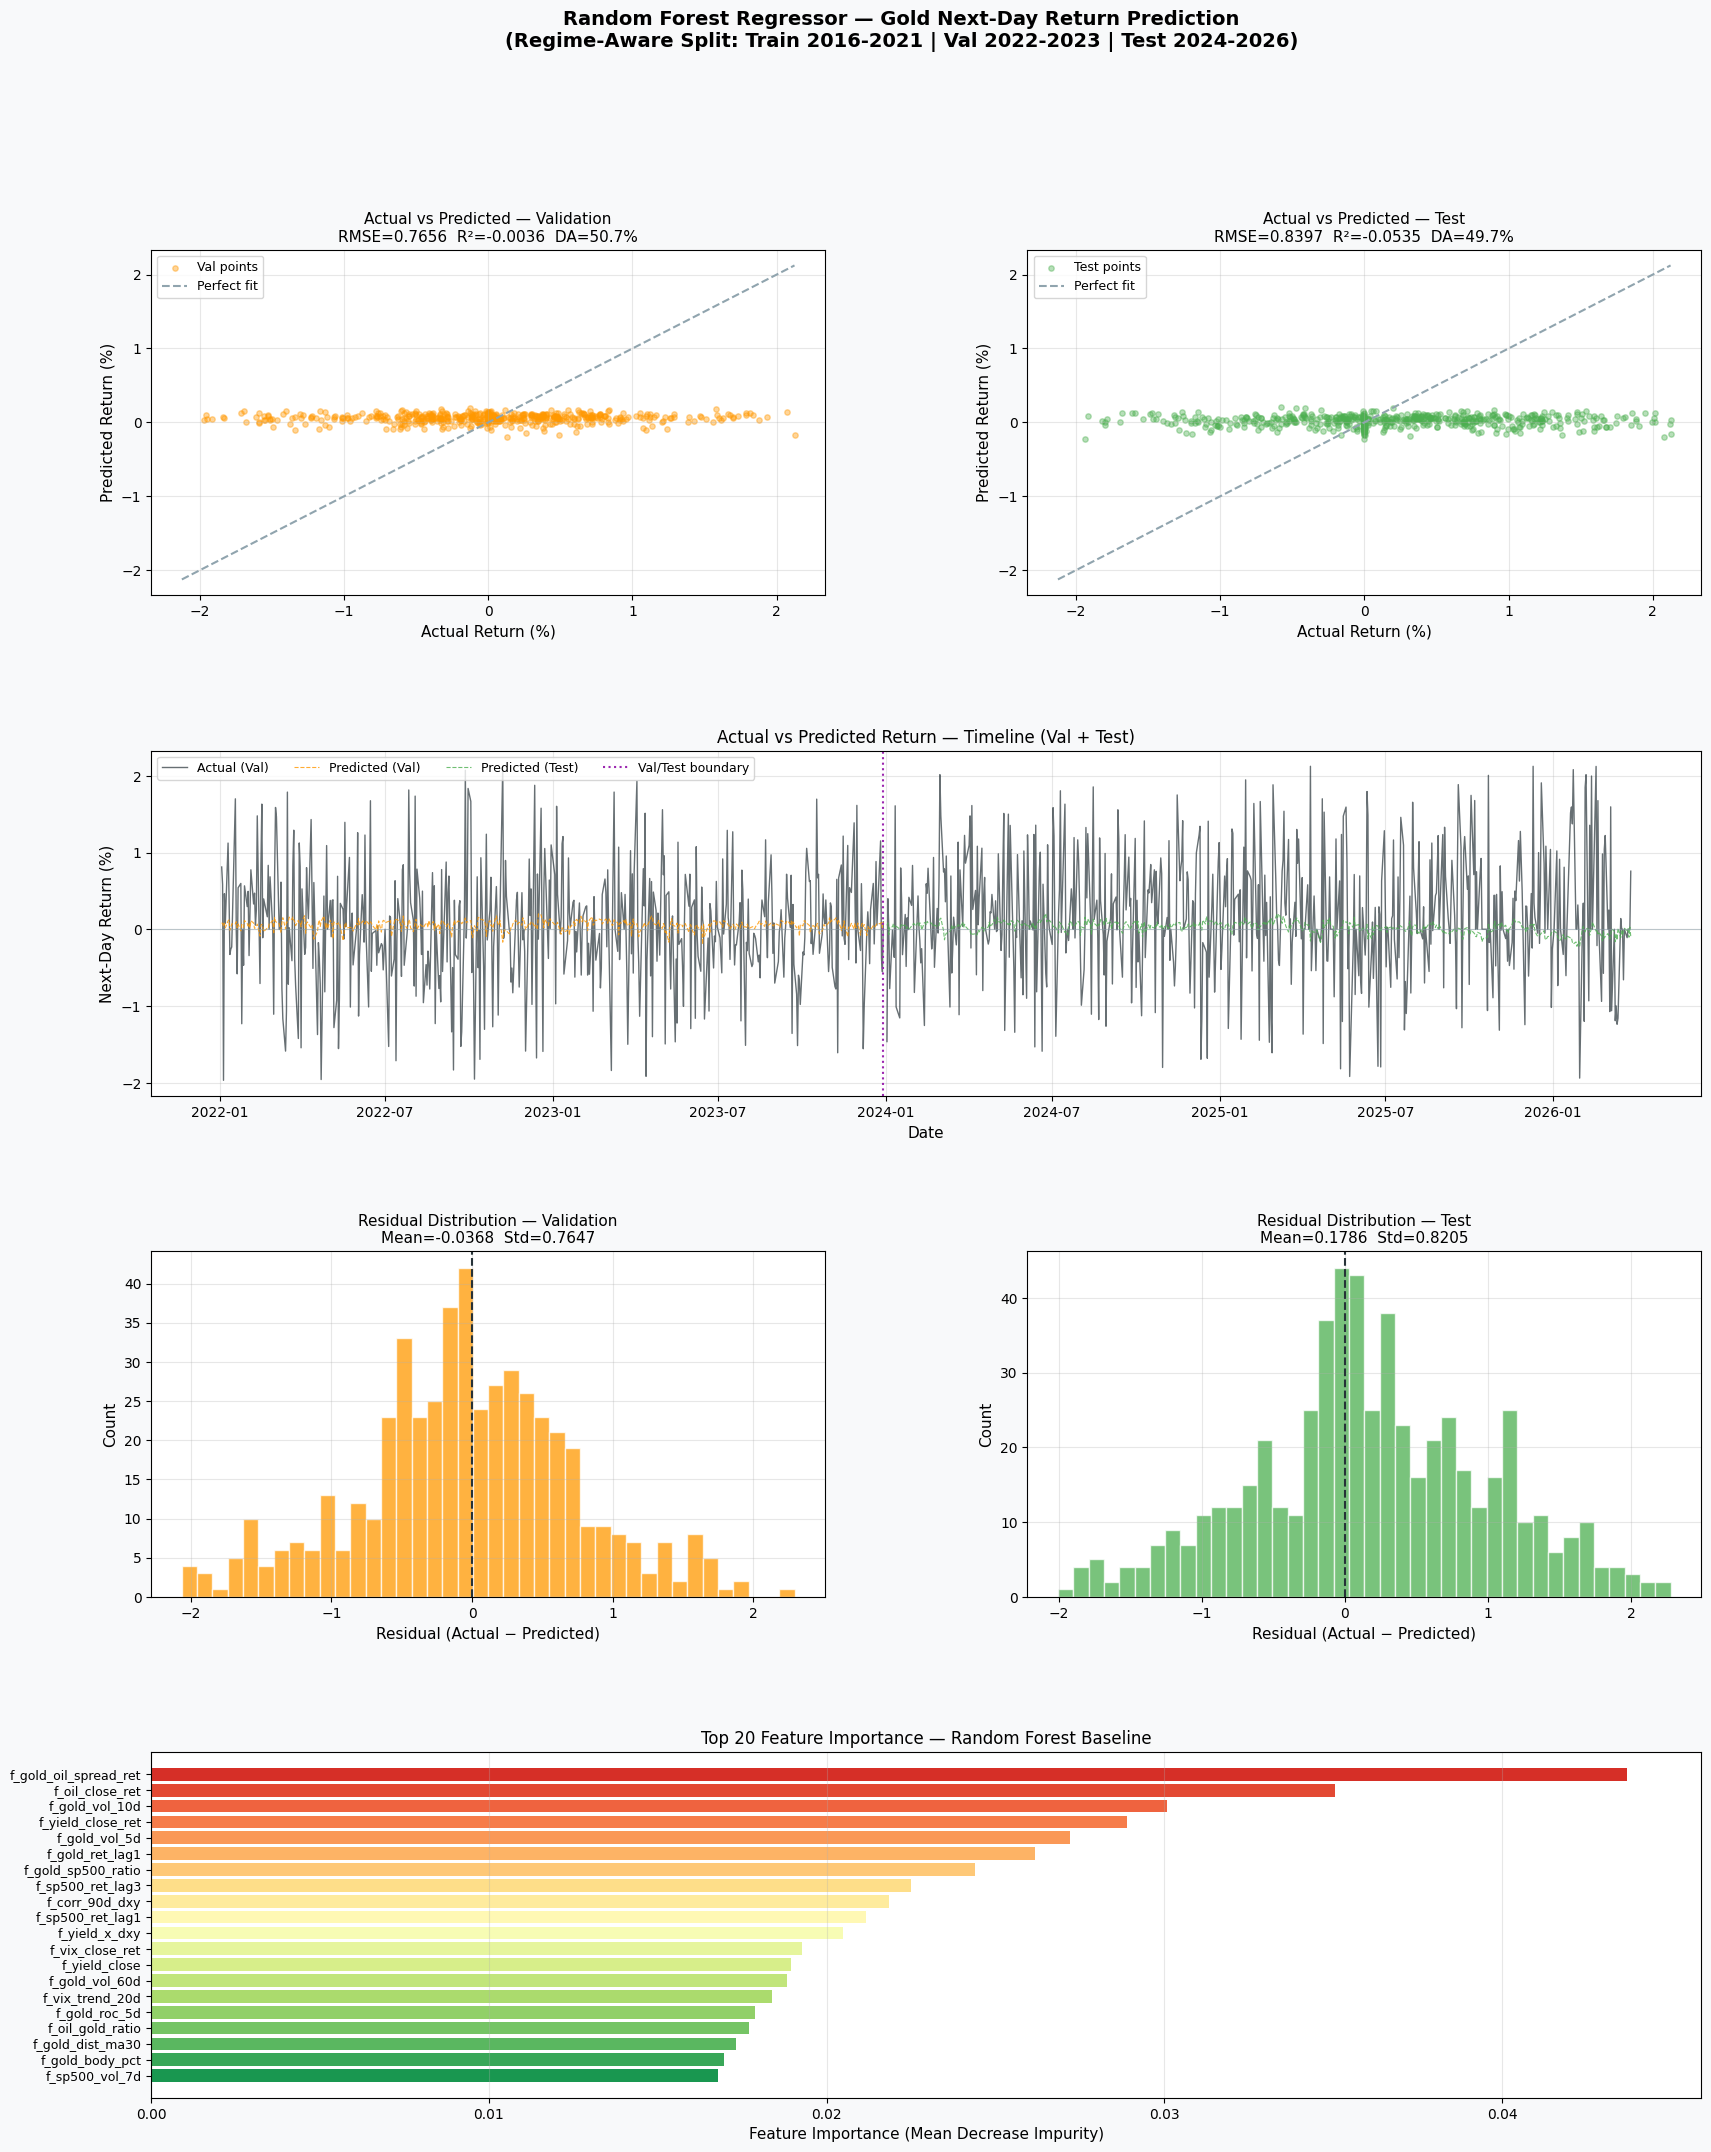

In [14]:
fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor("#F8F9FA")
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)
 
# ── [0,0] Actual vs Predicted — Val
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_val, y_pred_val, alpha=0.4, s=15, color=COLORS["val"], label="Val points")
lim = max(abs(y_val.min()), abs(y_val.max()))
ax1.plot([-lim, lim], [-lim, lim], "--", color=COLORS["zero"], lw=1.5, label="Perfect fit")
ax1.set_xlabel("Actual Return (%)", fontsize=11)
ax1.set_ylabel("Predicted Return (%)", fontsize=11)
ax1.set_title(f"Actual vs Predicted — Validation\nRMSE={metrics_val['rmse']:.4f}  R²={metrics_val['r2']:.4f}  DA={metrics_val['da']*100:.1f}%", fontsize=11)
ax1.legend(fontsize=9)
ax1.set_facecolor("#FFFFFF")
ax1.grid(True, alpha=0.3)
 
# ── [0,1] Actual vs Predicted — Test
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test, y_pred_test, alpha=0.4, s=15, color=COLORS["test"], label="Test points")
lim = max(abs(y_test.min()), abs(y_test.max()))
ax2.plot([-lim, lim], [-lim, lim], "--", color=COLORS["zero"], lw=1.5, label="Perfect fit")
ax2.set_xlabel("Actual Return (%)", fontsize=11)
ax2.set_ylabel("Predicted Return (%)", fontsize=11)
ax2.set_title(f"Actual vs Predicted — Test\nRMSE={metrics_test['rmse']:.4f}  R²={metrics_test['r2']:.4f}  DA={metrics_test['da']*100:.1f}%", fontsize=11)
ax2.legend(fontsize=9)
ax2.set_facecolor("#FFFFFF")
ax2.grid(True, alpha=0.3)
 
# ── [1, :] Actual vs Predicted Timeline — Val + Test
ax3 = fig.add_subplot(gs[1, :])
# Val
ax3.plot(y_val.index, y_val.values,       color=COLORS["actual"], lw=1.0, alpha=0.7, label="Actual (Val)")
ax3.plot(y_val.index, y_pred_val,          color=COLORS["val"],    lw=0.8, alpha=0.8, linestyle="--", label="Predicted (Val)")
# Test
ax3.plot(y_test.index, y_test.values,      color=COLORS["actual"], lw=1.0, alpha=0.7)
ax3.plot(y_test.index, y_pred_test,        color=COLORS["test"],   lw=0.8, alpha=0.8, linestyle="--", label="Predicted (Test)")
# Separator
ax3.axvline(x=y_val.index[-1], color="#9C27B0", lw=1.5, linestyle=":", label="Val/Test boundary")
ax3.axhline(y=0, color=COLORS["zero"], lw=0.8, alpha=0.5)
ax3.set_title("Actual vs Predicted Return — Timeline (Val + Test)", fontsize=12)
ax3.set_xlabel("Date", fontsize=11)
ax3.set_ylabel("Next-Day Return (%)", fontsize=11)
ax3.legend(fontsize=9, ncol=4)
ax3.set_facecolor("#FFFFFF")
ax3.grid(True, alpha=0.3)
 
# ── [2,0] Residual Distribution — Val
ax4 = fig.add_subplot(gs[2, 0])
residuals_val = y_val.values - y_pred_val
ax4.hist(residuals_val, bins=40, color=COLORS["val"], alpha=0.75, edgecolor="white")
ax4.axvline(0, color=COLORS["actual"], lw=1.5, linestyle="--")
ax4.set_title(f"Residual Distribution — Validation\nMean={residuals_val.mean():.4f}  Std={residuals_val.std():.4f}", fontsize=11)
ax4.set_xlabel("Residual (Actual − Predicted)", fontsize=11)
ax4.set_ylabel("Count", fontsize=11)
ax4.set_facecolor("#FFFFFF")
ax4.grid(True, alpha=0.3)
 
# ── [2,1] Residual Distribution — Test
ax5 = fig.add_subplot(gs[2, 1])
residuals_test = y_test.values - y_pred_test
ax5.hist(residuals_test, bins=40, color=COLORS["test"], alpha=0.75, edgecolor="white")
ax5.axvline(0, color=COLORS["actual"], lw=1.5, linestyle="--")
ax5.set_title(f"Residual Distribution — Test\nMean={residuals_test.mean():.4f}  Std={residuals_test.std():.4f}", fontsize=11)
ax5.set_xlabel("Residual (Actual − Predicted)", fontsize=11)
ax5.set_ylabel("Count", fontsize=11)
ax5.set_facecolor("#FFFFFF")
ax5.grid(True, alpha=0.3)
 
# ── [3, :] Feature Importance — Top 20
ax6 = fig.add_subplot(gs[3, :])
top_feat = feat_imp.head(top_n)
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, top_n))
bars = ax6.barh(range(top_n), top_feat.values[::-1], color=colors_bar)
ax6.set_yticks(range(top_n))
ax6.set_yticklabels(top_feat.index[::-1], fontsize=9)
ax6.set_xlabel("Feature Importance (Mean Decrease Impurity)", fontsize=11)
ax6.set_title(f"Top {top_n} Feature Importance — Random Forest Baseline", fontsize=12)
ax6.set_facecolor("#FFFFFF")
ax6.grid(True, axis="x", alpha=0.3)
 
fig.suptitle("Random Forest Regressor — Gold Next-Day Return Prediction\n(Regime-Aware Split: Train 2016-2021 | Val 2022-2023 | Test 2024-2026)",
             fontsize=14, fontweight="bold", y=0.98)
 
# plt.savefig("../reports/figures/6_rf_regression_results.png", dpi=150,
#             bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
# print("  ✔ บันทึก plot ที่ ../reports/figures/6_rf_regression_results.png")
 

# 8 : HYPERPARAMETER TUNING — RandomizedSearchCV + TimeSeriesSplit

In [15]:
param_dist = {
    "n_estimators"     : [100, 200, 300, 500],
    "max_depth"        : [4, 6, 8, 10, 12, None],
    "min_samples_split": [10, 20, 30, 50],
    "min_samples_leaf" : [5, 10, 15, 20],
    "max_features"     : ["sqrt", "log2", 0.5, 0.7],
}

In [16]:
tscv_tune = TimeSeriesSplit(n_splits=5)

In [17]:
rf_search = RandomizedSearchCV(
    estimator  = RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions = param_dist,
    n_iter     = 30,           # ลองแค่ 30 combinations (ประหยัดเวลา)
    scoring    = "neg_root_mean_squared_error",
    cv         = tscv_tune,    # ← TimeSeriesSplit ไม่ใช่ KFold!
    n_jobs     = -1,
    random_state = 42,
    verbose    = 1,
    refit      = True,         # refit ด้วย best params บน train set ทั้งหมด
)
 

In [18]:
print("\n  กำลัง RandomizedSearchCV... ")
rf_search.fit(X_train, y_train)


  กำลัง RandomizedSearchCV... 
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [4, 6, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [5, 10, ...], 'min_samples_split': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation stra

In [19]:
print(f"\n  ✔ Best CV RMSE : {-rf_search.best_score_:.4f}")
print(f"  Best Params:")
for k, v in rf_search.best_params_.items():
    print(f"    {k:<25}: {v}")


  ✔ Best CV RMSE : 0.6861
  Best Params:
    n_estimators             : 100
    min_samples_split        : 50
    min_samples_leaf         : 5
    max_features             : log2
    max_depth                : 4


In [20]:
# ── Evaluate best model
rf_best = rf_search.best_estimator_
 
y_pred_val_best  = rf_best.predict(X_val)
y_pred_test_best = rf_best.predict(X_test)
 
print("\n  ── ผลลัพธ์หลัง Tuning:")
metrics_val_best  = compute_metrics(y_val,  y_pred_val_best,  "VAL  (Tuned)")
metrics_test_best = compute_metrics(y_test, y_pred_test_best, "TEST (Tuned)")


  ── ผลลัพธ์หลัง Tuning:

  ── VAL  (Tuned) ──
  RMSE                        : 0.7661   (Naive RMSE: 0.7642)
  MAE                         : 0.5889
  R² Score                    : -0.0050
  Directional Accuracy (DA)   : 0.4910  (49.1%)
  Information Coefficient (IC): 0.0307

  ── TEST (Tuned) ──
  RMSE                        : 0.8355   (Naive RMSE: 0.8181)
  MAE                         : 0.6475
  R² Score                    : -0.0431
  Directional Accuracy (DA)   : 0.5311  (53.1%)
  Information Coefficient (IC): 0.0282


In [21]:
print(f"""
  ┌─ Baseline vs Tuned (Test Set) ─────────────────────────────────┐
  │  Metric          Baseline      Tuned       Δ                   │
  │  ──────────────────────────────────────────────────────────    │
  │  RMSE          {metrics_test['rmse']:>8.4f}    {metrics_test_best['rmse']:>8.4f}   {metrics_test_best['rmse']-metrics_test['rmse']:>+.4f}          │
  │  MAE           {metrics_test['mae']:>8.4f}    {metrics_test_best['mae']:>8.4f}   {metrics_test_best['mae']-metrics_test['mae']:>+.4f}          │
  │  R²            {metrics_test['r2']:>8.4f}    {metrics_test_best['r2']:>8.4f}   {metrics_test_best['r2']-metrics_test['r2']:>+.4f}          │
  │  DA (%)        {metrics_test['da']*100:>7.1f}%    {metrics_test_best['da']*100:>7.1f}%   {(metrics_test_best['da']-metrics_test['da'])*100:>+.1f}%         │
  │  IC            {metrics_test['ic']:>8.4f}    {metrics_test_best['ic']:>8.4f}   {metrics_test_best['ic']-metrics_test['ic']:>+.4f}          │
  └────────────────────────────────────────────────────────────────┘
""")


  ┌─ Baseline vs Tuned (Test Set) ─────────────────────────────────┐
  │  Metric          Baseline      Tuned       Δ                   │
  │  ──────────────────────────────────────────────────────────    │
  │  RMSE            0.8397      0.8355   -0.0042          │
  │  MAE             0.6528      0.6475   -0.0053          │
  │  R²             -0.0535     -0.0431   +0.0104          │
  │  DA (%)           49.7%       53.1%   +3.4%         │
  │  IC              0.0330      0.0282   -0.0048          │
  └────────────────────────────────────────────────────────────────┘



# 9. WALK-FORWARD CROSS-VALIDATION (บน Train Set)

In [22]:
tscv_wf = TimeSeriesSplit(n_splits=5)
wf_results = []
 
for fold, (tr_idx, vl_idx) in enumerate(tscv_wf.split(X_train), 1):
    X_tr_f = X_train.iloc[tr_idx]
    X_vl_f = X_train.iloc[vl_idx]
    y_tr_f = y_train.iloc[tr_idx]
    y_vl_f = y_train.iloc[vl_idx]
 
    rf_fold = RandomForestRegressor(**rf_best.get_params())
    rf_fold.fit(X_tr_f, y_tr_f)
    y_pred_f = rf_fold.predict(X_vl_f)
 
    fold_rmse = np.sqrt(mean_squared_error(y_vl_f, y_pred_f))
    fold_da   = directional_accuracy(y_vl_f, y_pred_f)
    fold_ic   = information_coefficient(y_vl_f, y_pred_f)
 
    wf_results.append({"fold": fold, "rmse": fold_rmse, "da": fold_da, "ic": fold_ic})
    print(f"  Fold {fold}: RMSE={fold_rmse:.4f}  DA={fold_da*100:.1f}%  IC={fold_ic:.4f}"
          f"  Val={X_train.index[vl_idx[0]].date()} → {X_train.index[vl_idx[-1]].date()}")
 
wf_df = pd.DataFrame(wf_results)
print(f"\n  Mean  | RMSE={wf_df['rmse'].mean():.4f} ± {wf_df['rmse'].std():.4f}"
      f"  DA={wf_df['da'].mean()*100:.1f}% ± {wf_df['da'].std()*100:.1f}%"
      f"  IC={wf_df['ic'].mean():.4f} ± {wf_df['ic'].std():.4f}")

  Fold 1: RMSE=0.6229  DA=56.5%  IC=0.1564  Val=2017-02-10 → 2018-02-02
  Fold 2: RMSE=0.6035  DA=44.7%  IC=0.0124  Val=2018-02-05 → 2019-01-28
  Fold 3: RMSE=0.6572  DA=45.5%  IC=0.0230  Val=2019-01-29 → 2020-01-17
  Fold 4: RMSE=0.8126  DA=48.4%  IC=0.0339  Val=2020-01-21 → 2021-01-11
  Fold 5: RMSE=0.7340  DA=53.3%  IC=0.0073  Val=2021-01-12 → 2021-12-31

  Mean  | RMSE=0.6861 ± 0.0865  DA=49.7% ± 5.1%  IC=0.0466 ± 0.0622


# 10 : SAVE PREDICTIONS & MODEL

In [23]:
import os, joblib
 
 
# บันทึก predictions
pred_val_df  = pd.DataFrame({"actual": y_val,  "predicted": y_pred_val_best},  index=y_val.index)
pred_test_df = pd.DataFrame({"actual": y_test, "predicted": y_pred_test_best}, index=y_test.index)
pred_val_df.to_csv("../../../data/processed/predictions/rf_reg_val_pred.csv")
pred_test_df.to_csv("../../../data/processed/predictions/rf_reg_test_pred.csv")
 
# บันทึกโมเดล
joblib.dump(rf_best, "../../../models/rf_regressor_best.pkl")
 
# บันทึก feature importance
feat_imp_tuned = pd.Series(rf_best.feature_importances_, index=X_train.columns) \
                   .sort_values(ascending=False)
feat_imp_tuned.to_csv("../../../data/processed/predictions/rf_reg_feature_importance.csv",
                      header=["importance"])
 
print("Saved:")
print("../../../data/processed/predictions/rf_reg_val_pred.csv")
print("../../../data/processed/predictions/rf_reg_test_pred.csv")
print("../../../data/processed/predictions/rf_reg_feature_importance.csv")
print("../models/rf_regressor_best.pkl")

Saved:
../../../data/processed/predictions/rf_reg_val_pred.csv
../../../data/processed/predictions/rf_reg_test_pred.csv
../../../data/processed/predictions/rf_reg_feature_importance.csv
../models/rf_regressor_best.pkl


#### FINAL SUMMARY

In [24]:
print("  FINAL SUMMARY — Random Forest Regressor")
print("=" * 70)
print(f"""
  Model    : RandomForestRegressor (Tuned via RandomizedSearchCV)
  CV       : TimeSeriesSplit (5 folds) — ไม่ shuffle
  Scaler   : RobustScaler (fit on Train only)
 
  ─── Test Set Performance ─────────────────────────────────────────
  RMSE                    : {metrics_test_best['rmse']:.4f}
  MAE                     : {metrics_test_best['mae']:.4f}
  R² Score                : {metrics_test_best['r2']:.4f}
  Directional Accuracy    : {metrics_test_best['da']*100:.1f}%
  Information Coefficient : {metrics_test_best['ic']:.4f}
 
  ─── Key Warnings ──────────────────────────────────────────────────
  ⚠  R² ต่ำเป็นเรื่องปกติในการทำนาย daily financial return
  ⚠  ใช้ DA และ IC เป็น primary metric แทน R²
  ⚠  ผล backtest ยังต้องพิจารณา transaction cost ก่อน deploy
 
  ─── Next Steps ────────────────────────────────────────────────────
  → Step 7: Classification Model (predict direction -1/0/+1)
  → Step 8: Ensemble (RF + GBM + LSTM)
  → Step 9: Backtest simulation with transaction cost
""")

  FINAL SUMMARY — Random Forest Regressor

  Model    : RandomForestRegressor (Tuned via RandomizedSearchCV)
  CV       : TimeSeriesSplit (5 folds) — ไม่ shuffle
  Scaler   : RobustScaler (fit on Train only)

  ─── Test Set Performance ─────────────────────────────────────────
  RMSE                    : 0.8355
  MAE                     : 0.6475
  R² Score                : -0.0431
  Directional Accuracy    : 53.1%
  Information Coefficient : 0.0282

  ─── Key Warnings ──────────────────────────────────────────────────
  ⚠  R² ต่ำเป็นเรื่องปกติในการทำนาย daily financial return
  ⚠  ใช้ DA และ IC เป็น primary metric แทน R²
  ⚠  ผล backtest ยังต้องพิจารณา transaction cost ก่อน deploy

  ─── Next Steps ────────────────────────────────────────────────────
  → Step 7: Classification Model (predict direction -1/0/+1)
  → Step 8: Ensemble (RF + GBM + LSTM)
  → Step 9: Backtest simulation with transaction cost

